# Semester group project (Semester B 25/26)

This file is the group project template for the whole semester, aiming for student to gain an insight into data analysing and engineering works.

This project is targeted at first year non-engineering and non-mathmetical student.

#### 数据采集
1.**采集网址：http://www.gudianmingzhu.com/guji/hongloumeng/11368.html**
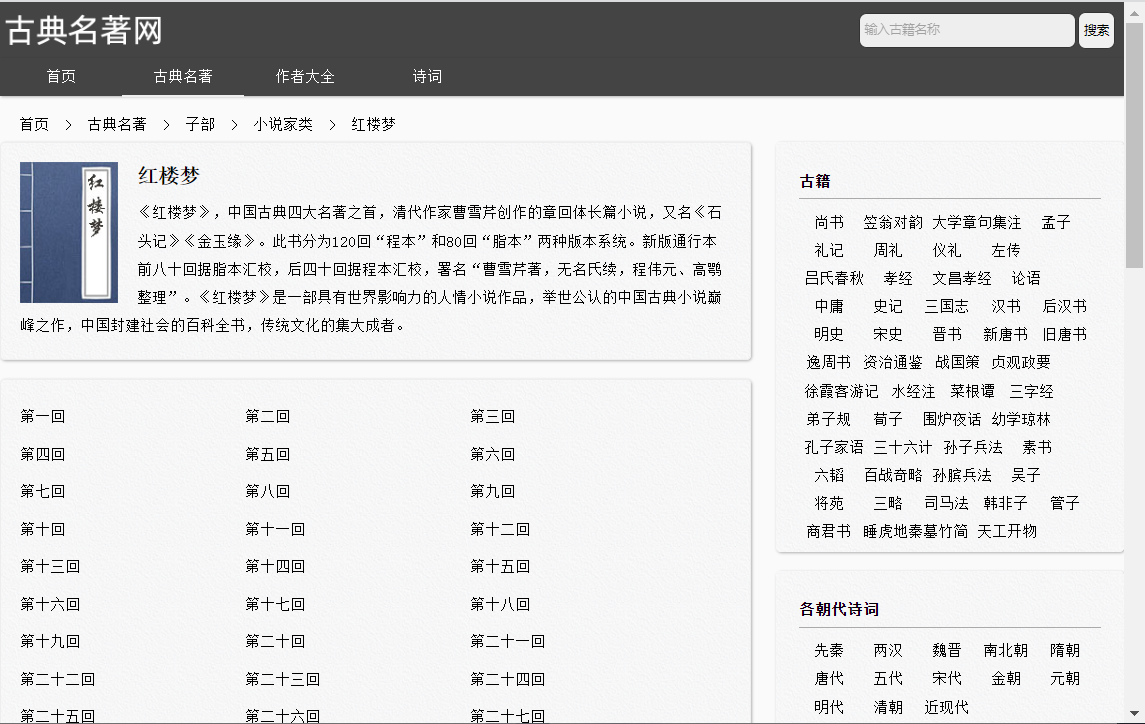

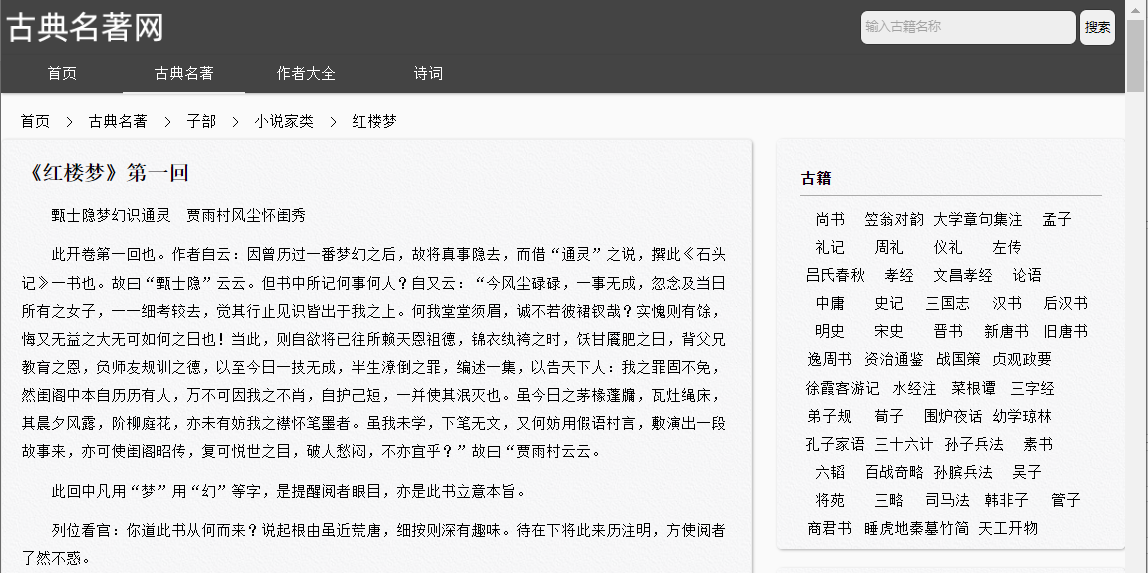

2.**八爪鱼采集器采集数据**
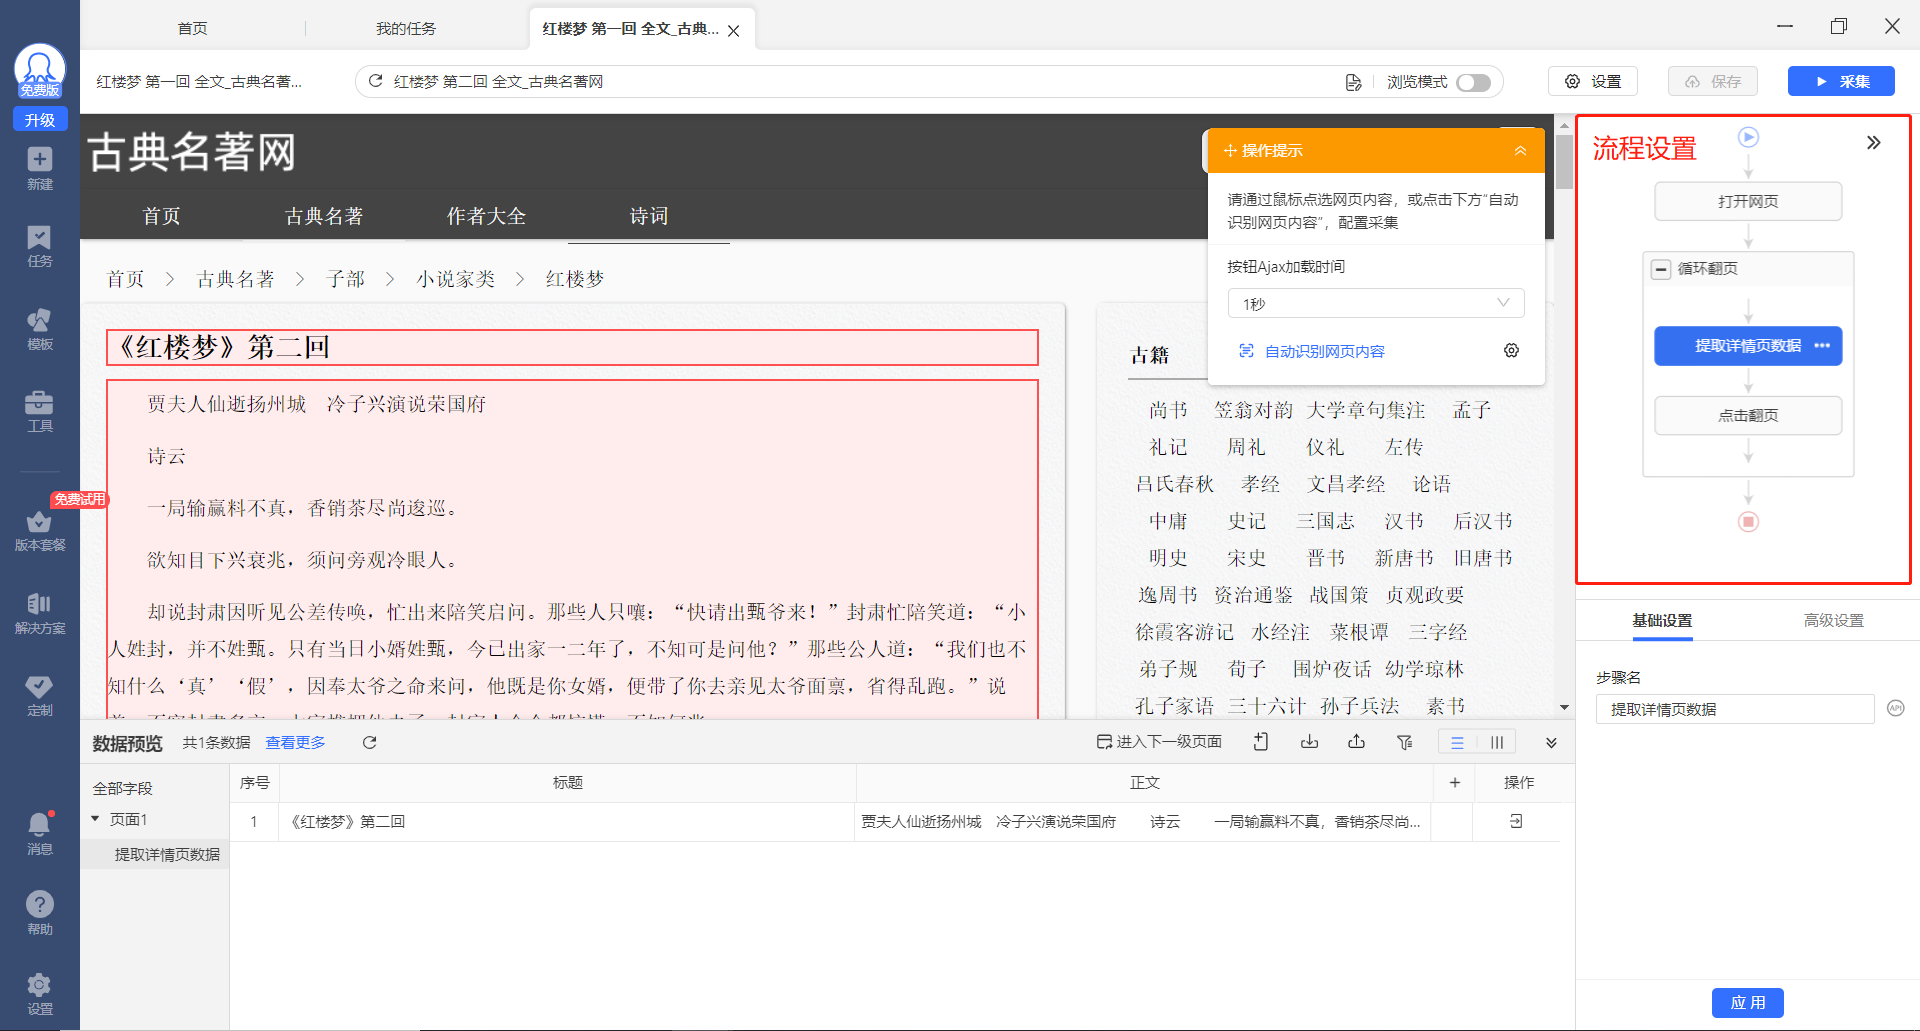

3. **数据导出为csv文件“红楼梦全文_古典名著网.csv”**
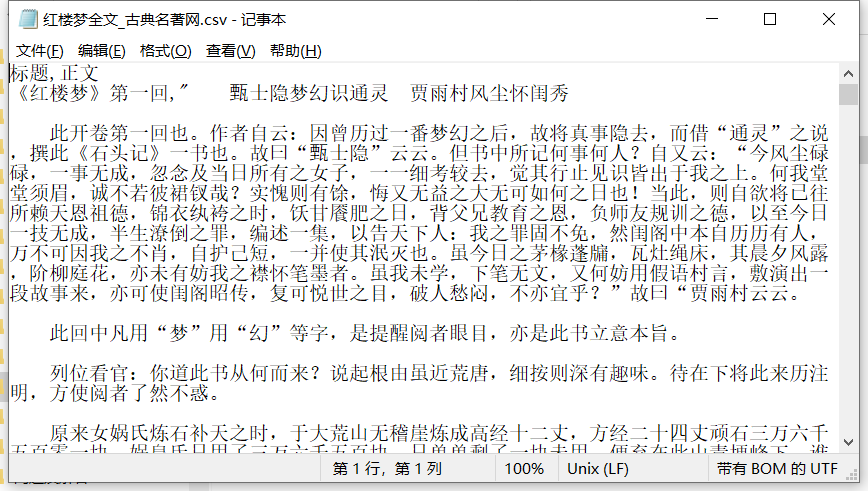

#### 数据清洗

In [ ]:
# 可手动删除文本第一行

#### 数据分析
1. 人物出场次数统计

人物（角色）出场次数统计较为通俗地解释了该人物（角色）的文学重力。

In [1]:
# 打开文件读取文件内容
fr = open('红楼梦全文_古典名著网.csv','r',encoding='utf-8')
txt = fr.read()   #将文件内容保存为一个字符串
fr.close()
print('文件打开成功')

In [2]:
import jieba.posseg as psg
fTxt = psg.lcut(txt)   #分词及词性标注
counts = {}
for wordpair in fTxt:
    word = wordpair.word    #词语
    fea = wordpair.flag     #词性
    if fea != 'nr':     #不是人名不统计
        continue
    if len(word) == 1:  #单字不统计
        continue
    elif word == '宝哥哥' or word == '宝玉曰' or word == '宝二爷' or word == '绛洞花主' \
                or word == '怡红公子' or word == '宝兄弟' or word == '混世魔王' or word == '宝玉':
        word = '宝玉'
    elif word == '黛玉' or word == '颦儿' or word == '潇湘妃子' or word == '林姑娘' or \
                word == '林妹妹' or word == '黛玉曰' or word == '颦颦' or word == '黛玉笑':
        word = '黛玉'
    elif word == '宝钗' or word == '宝钗曰' or word == '宝丫头' or word == '宝姐姐' or word == '薛大姑娘' or word =='宝钗笑':
        word = '宝钗'
    elif word == '熙凤' or word == '熙凤曰' or word == '琏二奶奶' or word == '凤辣子' or word == '凤哥儿' \
                or word == '凤丫头' or word == '凤姐' or word == '凤姐儿' or word == '琏二嫂子':
        word = '凤姐'
    elif word == '贾母' or word == '贾母曰' or word == '史太君' or word == '老祖宗' or word == '老太太' \
                or word == '老神仙':
        word = '贾母' 
    else:
        pass   #空语句
    counts[word] = counts.get(word,0) + 1    

items = list(counts.items())  #将字典转为列表
#排序，按照频率降序
items.sort(key=lambda x: x[1], reverse = True)
for i in range(10):
    word, count = items[i]
    print("{:<10}{:>5}".format(word, count))

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\lenovo\AppData\Local\Temp\jieba.cache
Loading model cost 0.997 seconds.
Prefix dict has been built successfully.


宝玉         3927
贾母         2317
凤姐         1684
黛玉         1187
王夫人        1005
宝钗          955
贾琏          681
薛姨妈         448
探春          432
贾政          429


In [3]:
#人物出场次数词云
import wordcloud

w = wordcloud.WordCloud(
    #width = 1000, height = 700,
    background_color = "white",   #设置背景颜色
    font_path = "msyh.ttc",    #中文必须制定字体    
    )       #生成词云对象
w.generate_from_frequencies(counts)  #加载字典，从词频建立词云
w.to_file("红楼梦人物.png")  #保存词云文件

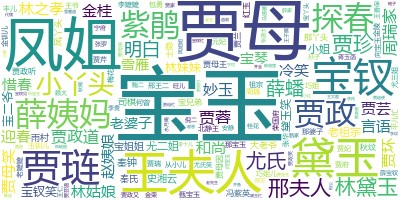

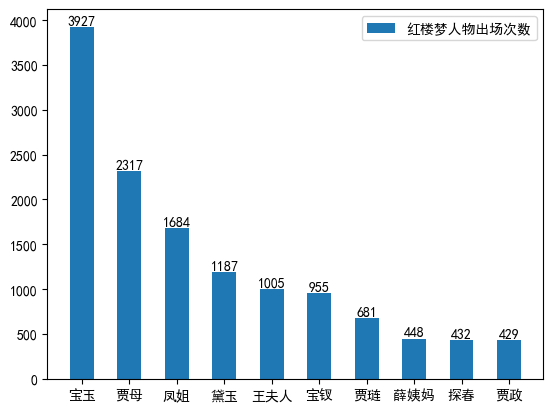

In [3]:
#人物出场次数条形图，只显示前十位人物
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'SimHei'   #设置中文字体

N = 10
y = [pe[1] for pe in items][:10]   #出场次数
x = [pe[0] for pe in items][:10]   # 人名
str1 = x
# 绘图 x x轴， height 高度, 默认：color="blue", width=0.8
p1 = plt.bar(x, height=y, width=0.5, label="红楼梦人物出场次数", tick_label=str1)
# 添加数据标签
for a, b in zip(x, y):  # (x[0],y[0])
    plt.text(a, b, '%.0f' % b, ha='center', va='bottom', fontsize=10)
plt.legend() # 添加图例
plt.show()   # 展示图形

In [4]:
print(len(items))
print(items)

3674
[('宝玉', 3773), ('贾母', 2231), ('凤姐', 1611), ('王夫人', 1005), ('黛玉', 871), ('宝钗', 746), ('贾琏', 681), ('薛姨妈', 448), ('探春', 432), ('贾政', 429), ('紫鹃', 409), ('小丫头', 289), ('邢夫人', 287), ('贾珍', 283), ('林黛玉', 283), ('尤氏', 268), ('薛蟠', 239), ('明白', 217), ('贾蓉', 177), ('贾政道', 171), ('周瑞家', 170), ('言语', 156), ('惜春', 150), ('林之孝', 143), ('迎春', 141), ('贾芸', 141), ('赵姨娘', 133), ('林姑娘', 130), ('贾母笑', 130), ('金桂', 127), ('妙玉', 125), ('冷笑', 124), ('和尚', 118), ('贾环', 116), ('老婆子', 107), ('雪雁', 105), ('宝琴', 105), ('宝钗笑', 99), ('林妹妹', 97), ('宝二爷', 95), ('尤二姐', 91), ('黛玉笑', 89), ('小姐', 87), ('老祖宗', 83), ('史湘云', 82), ('宝姐姐', 80), ('秦钟', 73), ('大老爷', 64), ('凤丫头', 64), ('雨村', 63), ('秦氏', 62), ('司棋', 61), ('贾母王', 61), ('贾兰', 60), ('宝兄弟', 59), ('士隐', 58), ('那丫头', 58), ('冯紫英', 58), ('贾政听', 58), ('秋纹', 58), ('红玉', 58), ('贾母因', 53), ('巧姐儿', 53), ('那婆子', 51), ('老嬷嬷', 49), ('贾瑞', 48), ('从小儿', 47), ('那宝玉', 46), ('王爷', 46), ('包勇', 46), ('邢王二', 44), ('北静王', 43), ('玉钏儿', 43), ('何曾', 41), ('丰儿', 41), ('巧姐', 41), ('祖宗'

2. 关键回目词云制作

C:\Users\lenovo\AppData\Local\Temp\ipykernel_12728\1901758015.py:21: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread("hlm.jpg")


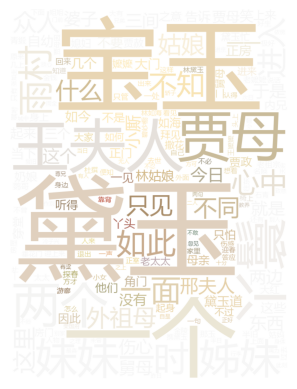

In [6]:
# 红楼梦第三回词云制作

import jieba
import wordcloud
import matplotlib.pyplot as plt

possta = txt.find('《红楼梦》第三回')
posend = txt.find('《红楼梦》第四回')
txt3 = txt[possta:posend]   # 得到第三回文本

words3 = jieba.lcut(txt3) #精确分词模式
ls3 = []
for word in words3:  #对每个词
    if len(word)>1:  #对非单字的词语
        ls3.append(word)
    
#词云汇总
chap3 = " ".join(ls3)      #用空格将所有词语合成一个长字符串

from imageio import imread
image = imread("hlm.jpg")
# 构造ImageColorGenerator
color_generator=wordcloud.ImageColorGenerator(image)

w = wordcloud.WordCloud(
    #width = 1000, height = 700,
    background_color = "white",   #设置背景颜色
    font_path = "msyh.ttc",    #中文必须制定字体
    mask = image,  #词云形状设置
    color_func=color_generator    #生成词云对象时候进行着色
    )       #生成词云对象
w.generate(chap3)  #加载字典，从词频建立词云
w.to_file("第三回词云.png")  #保存词云文件

plt.imshow(w) # 传入wordcloud对象
plt.axis('off') # 关闭坐标轴
plt.show() # 将图片展示出来

3. 主要人物语言情感分析

贾宝玉语言情感分析

宝玉早已看见多了一个姊妹，便料定是林姑妈之女，忙来作揖。厮见毕归坐，细看形容，与众各别：两弯似蹙非蹙罥烟眉，一双似喜非喜含情目。态生两靥之愁，娇袭一身之病。泪光点点，娇喘微微。闲静时如姣花照水，行动处似弱柳扶风。心较比干多一窍，病如西子胜三分。宝玉看罢，因笑道：“这个妹妹我曾见过的。”

宝玉看罢，因笑道：“这个妹妹我曾见过的。”


宝玉笑道：“虽然未曾见过他，然我看着面善，心里就算是旧相识，今日只作远别重逢，亦未为不可。”


In [7]:
# 第三回关于贾宝玉的语言情感分析
# 以含有宝玉的句子作为分析语句

from snownlp import SnowNLP

fj1 = txt3.split('”')   #将所有对话切片分解
lsfj = []
grade = 0  #保存情感分
for st in fj1:
    loc = st.find('“')  #找到这句话的开始位置
    last = st[:loc].split('。')[-1]   #找到'“'前最后一个句号
    loc2 = st.find(last)
    if '宝玉' in st[loc2:]:   #句子中含“宝玉”名字，即为与宝玉有关的话
        lsfj.append(st[loc:])   #对这句话做情感分析
        print(lsfj[-1])
        grade += SnowNLP(lsfj[-1]).sentiments  #生成中文文本处理对象
pj = grade/len(lsfj)
print('第三回与宝玉有关的情感得分是：',pj)
if pj > 0.7:
    print('正向情感')
elif pj > 0.4:
    print('中性情感')
else:
    print('消极情感')
        

“舅母说的，可是衔玉所生的这位哥哥？在家时亦曾听见母亲常说，这位哥哥比我大一岁，小名就唤宝玉，虽极憨顽，说在姊妹情中极好的。况我来了，自然只和姊妹同处，兄弟们自是别院另室的，岂得去沾惹之理？
“宝玉来了！
“这个宝玉，不知是怎生个惫{赖心}人物，懵懂顽童？－－倒不见那蠢物也罢了。心中想着，忽见丫鬟话未报完，已进来了一位年轻的公子：头上戴着束发嵌宝紫金冠，齐眉勒着二龙抢珠金抹额，穿一件二色金百蝶穿花大红箭袖，束着五彩丝攒花结长穗宫绦，外罩石青起花八团倭锻排穗褂，登着青缎粉底小朝靴。面若中秋之月，色如春晓之花，鬓若刀裁，眉如墨画，面如桃瓣，目若秋波。虽怒时而若笑，即瞋视而有情。项上金螭璎珞，又有一根五色丝绦，系着一块美玉。黛玉一见，便吃一大惊，心下想道：“好生奇怪，倒像在那里见过一般，何等眼熟到如此！
“去见你娘来。
“这个妹妹我曾见过的。
“虽然未曾见过他，然我看着面善，心里就算是旧相识，今日只作远别重逢，亦未为不可。
“妹妹可曾读书？
“妹妹尊名是那两个字？
“我送妹妹一妙字，莫若‘颦颦’二字极妙。
“《古今人物通考》上说：‘西方有石名黛，可代画眉之墨。’况这林妹妹眉尖若蹙，用取这两个字，岂不两妙！
“除《四书》外，杜撰的太多，偏只我是杜撰不成？
“什么罕物，连人之高低不择，还说‘通灵’不‘通灵’呢！我也不要这劳什子了！
“孽障！你生气，要打骂人容易，何苦摔那命根子！
“家里姐姐妹妹都没有，单我有，我说没趣，如今来了这们一个神仙似的妹妹也没有，可知这不是个好东西。
“今将宝玉挪出来，同我在套间暖阁儿里，把你林姑娘暂安置碧纱橱里。等过了残冬，春天再与他们收拾房屋，另作一番安置罢。
“好祖宗，我就在碧纱橱外的床上很妥当，何必又出来闹的老祖宗不得安静。
“花气袭人
“姑娘怎么还不安息？
第三回与宝玉有关的情感得分是： 0.7168112166358072
正向情感


In [9]:
print(fj1)   #输出每句话

['《红楼梦》第三回,"\u3000\u3000贾雨村夤缘复旧职\u3000林黛玉抛父进京都\n\n\u3000\u3000却说雨村忙回头看时，不是别人，乃是当日同僚一案参革的\n\n\u3000\u3000号张如圭者。他本系此地人，革后家居，今打听得都中奏准起复旧员之信，他便四下里寻情找门路，忽遇见雨村，故忙道喜。二人见了礼，张如圭便将此信告诉雨村，雨村自是欢喜，忙忙的叙了两句，遂作别各自回家。冷子兴听得此言，便忙献计，令雨村央烦林如海，转向都中去央烦贾政。雨村领其意，作别回至馆中，忙寻邸报看真确了。\n\n\u3000\u3000次日，面谋之如海。如海道：“天缘凑巧，因贱荆去世，都中家岳母念及小女无人依傍教育，前已遣了男女船只来接，因小女未曾大痊，故未及行。此刻正思向蒙训教之恩未经酬报，遇此机会，岂有不尽心图报之理。但请放心。弟已预为筹画至此，已修下荐书一封，转托内兄务为周全协佐，方可稍尽弟之鄙诚，即有所费用之例，弟于内兄信中已注明白，亦不劳尊兄多虑矣。', '雨村一面打恭，谢不释口，一面又问：“不知令亲大人现居何职？只怕晚生草率，不敢骤然入都干渎。', '如海笑道：“若论舍亲，与尊兄犹系同谱，乃荣公之孙：大内兄现袭一等将军，名赦，字恩侯，二内兄名政，字存周，现任工部员外郎，其为人谦恭厚道，大有祖父遗风，非膏粱轻薄仕宦之流，故弟方致书烦托。否则不但有污尊兄之清操，即弟亦不屑为矣。', '雨村听了，心下方信了昨日子兴之言，于是又谢了林如海。如海乃说：“已择了出月初二日小女入都，尊兄即同路而往，岂不两便？', '雨村唯唯听命，心中十分得意。如海遂打点礼物并饯行之事，雨村一一领了。\n\n\u3000\u3000那女学生黛玉，身体方愈，原不忍弃父而往，无奈他外祖母致意务去，且兼如海说：“汝父年将半百，再无续室之意，且汝多病，年又极小，上无亲母教养，下无姊妹兄弟扶持，今依傍外祖母及舅氏姊妹去，正好减我顾盼之忧，何反云不往？', '黛玉听了，方洒泪拜别，随了奶娘及荣府几个老妇人登舟而去。雨村另有一只船，带两个小童，依附黛玉而行。\n\n\u3000\u3000有日到了都中，进入神京，雨村先整了衣冠，带了小童，拿着宗侄的名帖，至荣府的门前投了。彼时贾政已看了妹丈之书，即忙请入相会。见雨村相貌魁伟，言语不俗，且这贾政最喜读书人，礼贤下士，济弱扶危，大有祖风；况又系妹丈致意，因

4. 人物关系网络分析

采用共现分析

共现分析法最早利用文献集中词汇对或名词短语共同出现的情况, 来确定该文献集所代表学科中各主题之间的关系，巧妙地把众多分析实体之间盘根错节的网状关系简化为以数值、图形的形式直观地表示出来[1]。通常词汇对在同一篇文献中出现的次数越多, 则代表这两个词汇的关系越紧密。

基于共词分析法的基础理论，将红楼梦作品中的每一个段落视为书中人物登场演出的一个舞台，一个共现单元，依此统计角色与角色之间的共现频次或者说交往关系强度。


In [7]:
# 选取词频排前50的人物进行共现分析
persons_all = [it[0] for it in items]
persons = persons_all[:50]
print(persons)

['宝玉', '贾母', '凤姐', '黛玉', '王夫人', '宝钗', '贾琏', '薛姨妈', '探春', '贾政', '紫鹃', '小丫头', '邢夫人', '贾珍', '林黛玉', '尤氏', '薛蟠', '明白', '贾蓉', '贾政道', '周瑞家', '言语', '惜春', '林之孝', '迎春', '贾芸', '赵姨娘', '贾母笑', '金桂', '妙玉', '冷笑', '和尚', '贾环', '老婆子', '雪雁', '宝琴', '尤二姐', '小姐', '史湘云', '秦钟', '大老爷', '雨村', '秦氏', '司棋', '贾母王', '贾兰', '士隐', '那丫头', '冯紫英', '贾政听']


In [16]:
# 打开文件读取文件内容,每段一个字符串，在lines列表里
fr = open('红楼梦全文_古典名著网.csv','r',encoding='utf-8')
lines = fr.readlines()   #将文件内容保存为一个字符串
fr.close()

In [18]:
relation = {}  #建立人物共现字典，一种粗略方法，没有考虑一个人有多名字或者称呼
for line in lines:
    for n1 in persons:
        for n2 in persons:
            if (n1 != n2) and (n1 in line) and (n2 in line):
                names = n1 + '-' + n2
                relation[names] = relation.get(names,0) + 1
print(relation.items())
    

dict_items([('和尚-雨村', 1), ('雨村-和尚', 1), ('宝玉-贾政', 168), ('宝玉-贾珍', 48), ('宝玉-贾蓉', 33), ('宝玉-小姐', 28), ('贾政-宝玉', 168), ('贾政-贾珍', 45), ('贾政-贾蓉', 18), ('贾政-小姐', 3), ('贾珍-宝玉', 48), ('贾珍-贾政', 45), ('贾珍-贾蓉', 63), ('贾珍-小姐', 8), ('贾蓉-宝玉', 33), ('贾蓉-贾政', 18), ('贾蓉-贾珍', 63), ('贾蓉-小姐', 4), ('小姐-宝玉', 28), ('小姐-贾政', 3), ('小姐-贾珍', 8), ('小姐-贾蓉', 4), ('冷笑-雨村', 5), ('雨村-冷笑', 5), ('宝玉-雨村', 10), ('雨村-宝玉', 10), ('明白-雨村', 7), ('雨村-明白', 7), ('探春-言语', 15), ('探春-惜春', 42), ('探春-迎春', 37), ('探春-小姐', 8), ('探春-雨村', 1), ('言语-探春', 15), ('言语-惜春', 15), ('言语-迎春', 9), ('言语-小姐', 5), ('言语-雨村', 4), ('惜春-探春', 42), ('惜春-言语', 15), ('惜春-迎春', 32), ('惜春-小姐', 3), ('惜春-雨村', 1), ('迎春-探春', 37), ('迎春-言语', 9), ('迎春-惜春', 32), ('迎春-小姐', 6), ('迎春-雨村', 1), ('小姐-探春', 8), ('小姐-言语', 5), ('小姐-惜春', 3), ('小姐-迎春', 6), ('小姐-雨村', 2), ('雨村-探春', 1), ('雨村-言语', 4), ('雨村-惜春', 1), ('雨村-迎春', 1), ('雨村-小姐', 2), ('贾琏-雨村', 5), ('雨村-贾琏', 5), ('黛玉-林黛玉', 142), ('黛玉-雨村', 5), ('林黛玉-黛玉', 142), ('林黛玉-雨村', 1), ('雨村-黛玉', 5), ('雨村-林黛玉', 1), ('贾政-雨村', 11), ('雨村-贾政', 11)

In [22]:
lsa = []
for k,v in relation.items():
    k1,k2 = k.split('-')
    if v > 3:   # 选共同出现3次以上的
        lsa.append([k1,k2,v])

In [23]:
print(lsa)

[['宝玉', '贾政', 168], ['宝玉', '贾珍', 48], ['宝玉', '贾蓉', 33], ['宝玉', '小姐', 28], ['贾政', '宝玉', 168], ['贾政', '贾珍', 45], ['贾政', '贾蓉', 18], ['贾珍', '宝玉', 48], ['贾珍', '贾政', 45], ['贾珍', '贾蓉', 63], ['贾珍', '小姐', 8], ['贾蓉', '宝玉', 33], ['贾蓉', '贾政', 18], ['贾蓉', '贾珍', 63], ['贾蓉', '小姐', 4], ['小姐', '宝玉', 28], ['小姐', '贾珍', 8], ['小姐', '贾蓉', 4], ['冷笑', '雨村', 5], ['雨村', '冷笑', 5], ['宝玉', '雨村', 10], ['雨村', '宝玉', 10], ['明白', '雨村', 7], ['雨村', '明白', 7], ['探春', '言语', 15], ['探春', '惜春', 42], ['探春', '迎春', 37], ['探春', '小姐', 8], ['言语', '探春', 15], ['言语', '惜春', 15], ['言语', '迎春', 9], ['言语', '小姐', 5], ['言语', '雨村', 4], ['惜春', '探春', 42], ['惜春', '言语', 15], ['惜春', '迎春', 32], ['迎春', '探春', 37], ['迎春', '言语', 9], ['迎春', '惜春', 32], ['迎春', '小姐', 6], ['小姐', '探春', 8], ['小姐', '言语', 5], ['小姐', '迎春', 6], ['雨村', '言语', 4], ['贾琏', '雨村', 5], ['雨村', '贾琏', 5], ['黛玉', '林黛玉', 142], ['黛玉', '雨村', 5], ['林黛玉', '黛玉', 142], ['雨村', '黛玉', 5], ['贾政', '雨村', 11], ['雨村', '贾政', 11], ['贾政', '言语', 34], ['言语', '贾政', 34], ['黛玉', '林姑娘', 45], ['林黛玉', '林姑娘', 9], ['林姑娘

In [ ]:
#去除重复人物对（略）

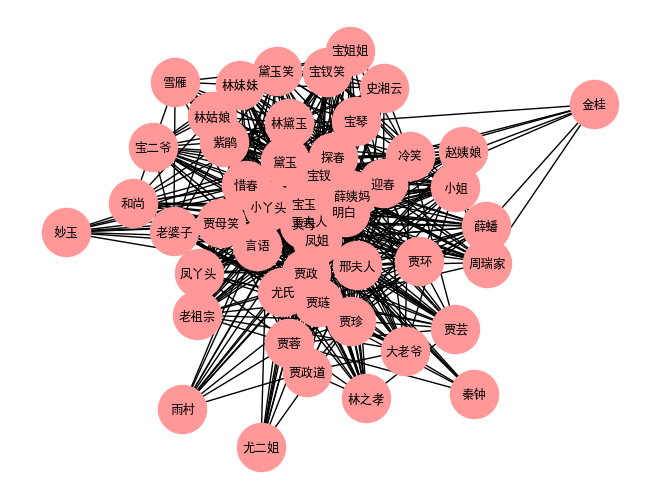

In [26]:
import networkx as nx
import matplotlib.pyplot as plt
from pylab import mpl
mpl.rcParams['font.sans-serif'] = ['SimHei'] # 指定默认字体
mpl.rcParams['axes.unicode_minus']

G = nx.Graph()
G.add_weighted_edges_from(lsa)
nx.draw(G,with_labels=True,font_size=9,node_size=1200,node_color='#FF9999')

plt.savefig('lp1.png')
plt.show()


5.参考资料

[1] 钟伟金,李佳.共词分析法研究(一)——共词分析的过程与方式[J].情报杂志,2008(05):70-72.

[2] 这就是读懂红楼梦的DNA密码？——数据话红楼，网络绘人心 第一篇, 网址 https://zhuanlan.zhihu.com/p/347973784?utm_id=0



6.思考

对红楼梦进行更多分析，如动词词频分析；前80回与后40回虚词分析；角色影响力分析；角色生命力分析等。


角色影响力

角色影响力由网络节点的加权度中心性决定，角色影响力越大，说明该角色在作品中与越多的人产生关联，作品的文学地位越高；

角色生命力（PF-PCF，Person_Frequency × Positive_Chapter_Frequency）

角色生命力指角色在每一回目出现频次占该章节出现的总人数的比例的回目之和，乘以总回目数除以角色出现的回目数，该指标参考了自然语言处理中衡量词向量重要性时常用的TF-IDF算法，角色生命力越大，说明该角色在《红楼梦》的活跃程度高、生命周期长，因而就越重要；

角色在哪些回目出现过，占总回目数的比例。比例越高，越能说明该人物是线索人物。

角色在回目出现的频次，占回目总角色出现次数的比例。比例越高，越能说明该人物在回目的重要性。

分析某个人物的角色影响力和角色生命力。



# This is the ending of this document.